In [69]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl

# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [70]:
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/emperical_fit_T1.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/emperical_fit_T2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_T2 = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/emperical_fit_FO.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_FO = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Ontogeny Output/DDM/T1 Precursor/DDM_T1_Division_dependent.pkl'
with open(file_path, 'rb') as f:
    data_neutral_T1 = pkl.load(f)
    

print(df_new.head(10))
print(df_ont.head(10))

                               Unnamed: 0  Age at BMT  Age at S1K  \
0  20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1  20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2      20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3      20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4        20181207_3wks_SPLEEN_001_048.fcs          74          95   
5        20181207_3wks_SPLEEN_002_049.fcs          41          62   
6        20181213_4wks_SPLEEN_001_024.fcs          74         102   
7        20181213_4wks_SPLEEN_002_025.fcs          41          69   
8   20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9   20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   

   Days postBMT  Lamis ID      total_FM     fd_FM  frac_Ki67+_FM_donor  \
0            14    832634  2.247009e+07  0.016125             0.441377   
1            14    848687  2.440681e+07  0.013667             0.485563   
2            18   

14298238.413685847


/tmp/ipykernel_2299993/1062625556.py:13: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


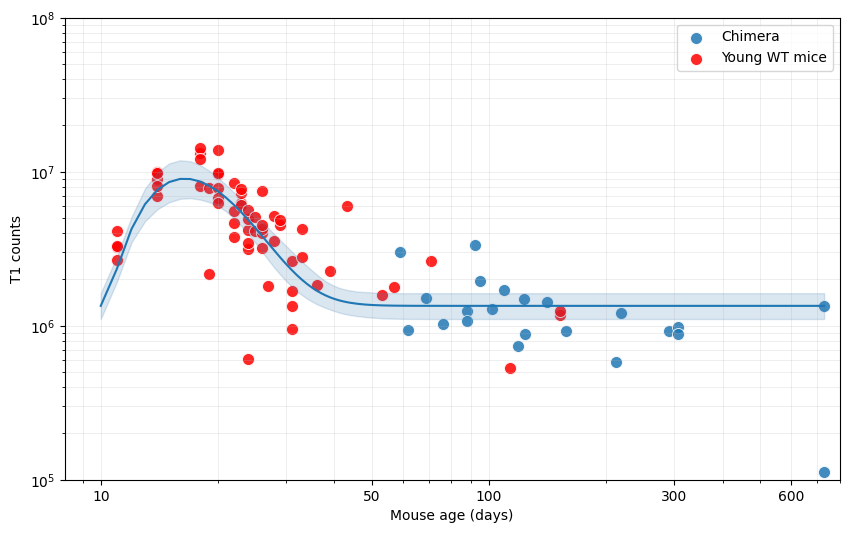

In [71]:
# Plot T1 AA4.1 counts
t_ev =np.array(np.arange(10,731,1))
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=75, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=75, color = 'Red',label='Young WT mice', legend=False)
print(np.max(df_ont['T1 AA4.1+_total']))
# plt.axhline(y=1298783, color='grey', linestyle='--', label='Adult')
plt.plot(t_ev, np.mean(data_neutral.T1_counts_pred, axis=0))
plt.fill_between(t_ev, np.quantile(data_neutral.T1_counts_pred, 0.025, axis=0), np.quantile(data_neutral.T1_counts_pred, 0.975, axis=0), color = 'steelblue', alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T1 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [72]:
print(np.mean(data_neutral.theta_0))
print(np.mean(data_neutral.nu))
print(np.mean(data_neutral.n))

14.1076865
0.30780698874999995
1.9940437174999999


In [76]:
def P(t):
    theta_0 = np.exp(np.mean(data_T2.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
 
def b(M, rho, M_stable, K):
    b = rho/(1 - (M_stable / K))
    return b * (1 -  (M / K))
 
# Define the ODE function
def ode_function(t, M, phi, rho, delta, M_stable, K, P):
    dMdt = phi * P(t) - (delta - b(M, rho, M_stable, K)) * M
    return np.array(dMdt)


# Define the parameters as array
# phi = data_neutral_T1.stan_variable('phi')
lamda_samples = data_neutral_T1.stan_variable('delta') - data_neutral_T1.stan_variable('rho')
M_stable_samples = data_neutral_T1.stan_variable('M_stable')

# phi = (lamda_samples * M_stable_samples)/ 1308516
phi = (lamda_samples * M_stable_samples)/ 1298783

rho = data_neutral_T1.stan_variable('rho')
delta = data_neutral_T1.stan_variable('delta')
M_stable = data_neutral_T1.stan_variable('M_stable')
K = data_neutral_T1.stan_variable('K')

# phi = 0.019
# rho = 0.025
# delta = 0.035
# M_stable = np.exp(14)
# K = np.exp(15)

# delta = ((phi * 1298783) / M_stable[:,0] ) + rho


#Initial conditions at time t=40
M0 = [12058]


t_ev = np.arange(11, 750, 0.001)

sol = np.zeros((len(data_neutral_T1.rho), len(t_ev)))
for i in range(len(data_neutral_T1.rho)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], M_stable[i], K[i], P))
    sol[i, :] = result.y[0]
# sol = solve_ivp(ode_function, [11, 750], M0, t_eval= t_ev, args=(phi, rho, delta, M_stable,K, P)).y[0]

print(sol.shape)



(8000, 739000)


/tmp/ipykernel_2299993/4259046401.py:18: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


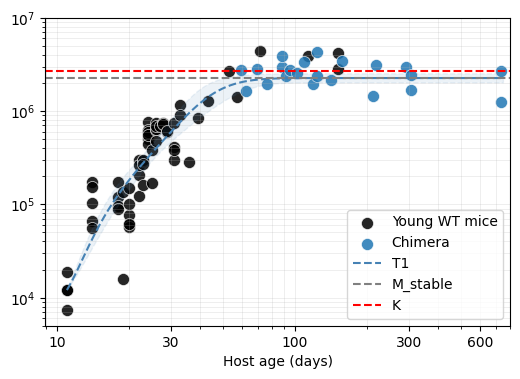

In [77]:
# Plot the Mz counts
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=75, color= 'black',label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=75, label='Chimera', legend=False,  linewidth=0.5)

plt.plot(t_ev, np.mean(sol, axis=0), linestyle= 'dashed', color = 'steelblue', label = 'T1')
# plt.plot(t_ev, sol, color = 'steelblue', label = 'T1')
plt.axhline(y=np.mean(M_stable), color='grey', linestyle='--', label='M_stable')
plt.axhline(y=np.mean(K), color='red', linestyle='--', label='K')
# plt.plot(t_ev, np.mean(solFO, axis=0), linestyle= 'dotted', color = 'steelblue', label = 'FO')
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.1, linestyle= 'dashed')
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(solFO, 0.025, axis=0), np.quantile(solFO, 0.975, axis=0), color = 'steelblue',alpha=0.2, linestyle= 'dotted')

plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
# plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in constant birth-loss model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend(loc = 'lower right')
# plt.tight_layout()

#save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny_predictions.pdf', dpi=300)
plt.show()



NameError: name 'solFO' is not defined

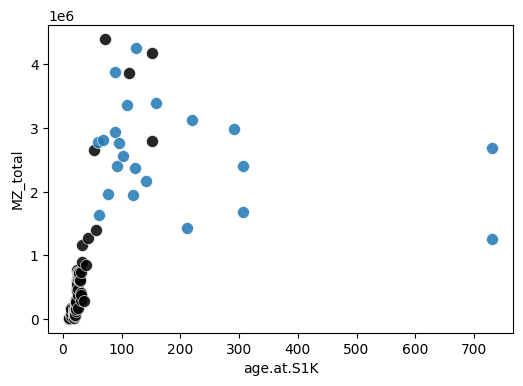

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=75, color= 'black',label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=75, label='Chimera', legend=False, linewidth=0.5)
plt.plot(t_ev, np.mean(solFO, axis=0), linestyle= 'dotted', color = 'steelblue', label = 'FO')
plt.fill_between(t_ev, np.quantile(solFO, 0.025, axis=0), np.quantile(solFO, 0.975, axis=0), color = 'steelblue',alpha=0.2, linestyle= 'dotted')

plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in constant birth-loss model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend(loc = 'lower right')
# plt.tight_layout()

#save the figure
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny_predictions_FO.pdf', dpi=300)
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def rho_func(t, rho_var, r_d_val):
    return rho_var / (1 + t/r_d_val) 


def delta_func(t, phi_val, rho_val, r_d_val, mz_counts_val):
    delta = ((phi_val * 1298783) / mz_counts_val) + (rho_val / (1 + t / r_d_val))
    return delta

# Define the ODE function
def ode_function(t, M, phi_val, rho_val, r_d_val, mz_counts_val, P):
    rho_t = rho_func(t, rho_val, r_d_val)
    delta_t = delta_func(t, phi_val, rho_val, r_d_val, mz_counts_val)
    dMdt = phi_val * P(t) - (delta_t - rho_t) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral_TDD.stan_variable('phi')  #Influx rate
rho_values = data_neutral_TDD.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_values = data_neutral_TDD.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral_TDD.stan_variable('MZ_counts_pred1')[:,0]

sol1 = np.zeros((len(rho_values), len(t_ev)))
for i in range(len(rho_values)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_values[i], r_d_values[i], mz_counts[i], P))
    sol1[i, :] = result.y[0]




KeyboardInterrupt: 

/tmp/ipykernel_448551/3422128698.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


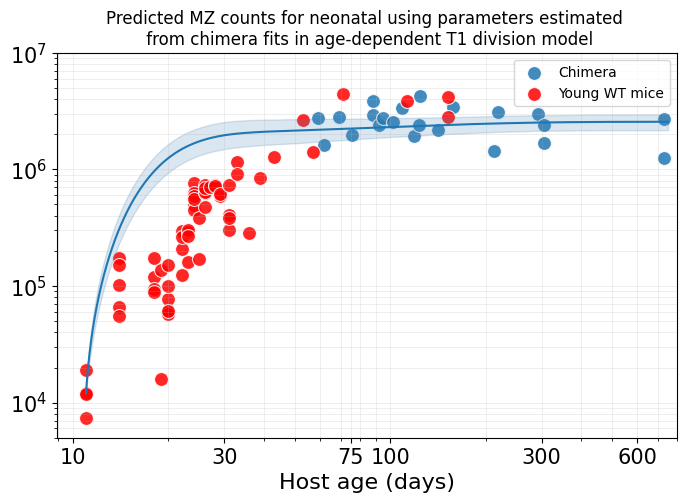

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol1, axis=0))
plt.fill_between(t_ev, np.quantile(sol1, 0.025, axis=0), np.quantile(sol1, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T1 division model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_division_T1.png', dpi=300)
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    n = np.mean(data_neutral.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi_func(t, phi, r_d_val):
    return phi * np.exp(-r_d_val * (t-40))


def delta_func(t, phi, rho_val, r_d_val, mz_counts):
    delta = (((phi * np.exp(-r_d_val * (t-40))) * 1298783) / mz_counts) + rho_val
    return delta

# Define the ODE function
def ode_function(t, M, phi, rho_val, r_d_val, mz_counts, P):
    phi_t = phi_func(t, phi, r_d_val)
    delta_t = delta_func(t, phi_t, rho_val, r_d_val, mz_counts)
    dMdt = phi_t * P(t) - (delta_t - rho_val) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral_TDI.stan_variable('phi')  #Influx rate
rho_val = data_neutral_TDI.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_val = data_neutral_TDI.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral_TDI.stan_variable('MZ_counts_pred1')[:,0]

sol2 = np.zeros((len(rho_val), len(t_ev)))
for i in range(len(rho_val)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_val[i], r_d_val[i], mz_counts[i], P))
    sol2[i, :] = result.y[0]


/tmp/ipykernel_448551/3525834296.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


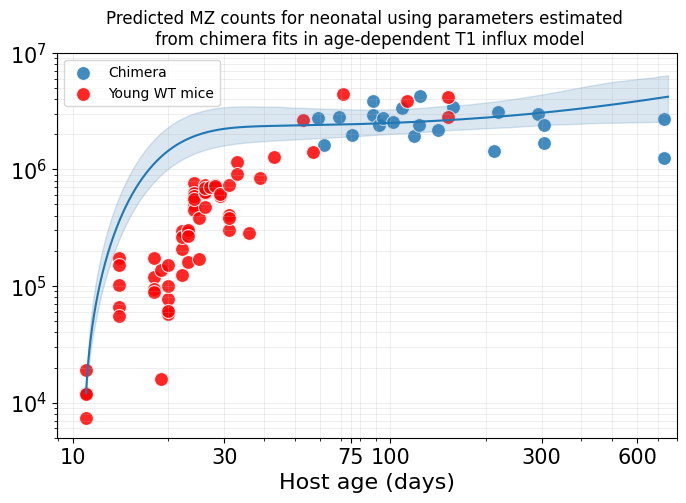

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol2, axis=0))
plt.fill_between(t_ev, np.quantile(sol2, 0.025, axis=0), np.quantile(sol2, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T1 influx model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_influx_T1.png', dpi=300)
plt.show()